# A first look at the transactions

Exploratory only. The benchmark itself lives in `src/` and runs with `python -m src.pipeline`. The aim here is to see what the data forces on the design: the metric, the split, the clipping bounds for differential privacy, and how synthetic data gets generated.

In [1]:
import sys
sys.path.insert(0, '..')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import DATA_PATH
from src.features.transform import engineer
from src.ingest.load import V_COLUMNS, load_transactions

BLUE, INK, MUTED, GRID = '#2a78d6', '#52514e', '#898781', '#e1e0d9'
plt.rcParams.update({'font.family': 'Segoe UI', 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.edgecolor': '#c3c2b7',
                     'axes.labelcolor': INK, 'xtick.color': INK, 'ytick.color': INK,
                     'figure.dpi': 110})

df = load_transactions('..' / DATA_PATH.relative_to(DATA_PATH.parents[1]))
frauds = int(df['Class'].sum())
print(f'{len(df):,} transactions, {frauds} frauds ({frauds / len(df):.3%})')
print(f'Accuracy of flagging nothing at all: {1 - frauds / len(df):.2%}')

284,807 transactions, 492 frauds (0.173%)
Accuracy of flagging nothing at all: 99.83%


## The class balance rules out accuracy

A model that never flags anything is 99.8% accurate and catches no fraud. The benchmark uses **AUPRC** (area under the precision-recall curve) instead, where a random guess scores about the fraud rate, and every split is stratified so each part keeps the same few frauds per thousand.

In [2]:
amount = df.groupby('Class')['Amount'].describe(percentiles=[0.5, 0.9, 0.99])
amount.index = ['Legitimate', 'Fraud']
amount[['count', 'mean', '50%', '90%', '99%', 'max']].round(2)

,count,mean,50%,90%,99%,max
Legitimate,284315.0,88.29,22.00,202.72,1016.97,25691.16
Fraud,492.0,122.21,9.25,346.75,1357.43,2125.87


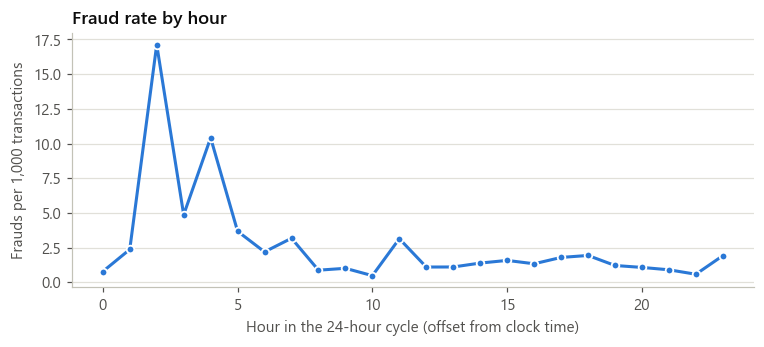

In [3]:
features = engineer(df)
by_hour = df.assign(hour=features['hour'].astype(int)).groupby('hour')['Class'].mean()

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(by_hour.index, by_hour.values * 1000, color=BLUE, linewidth=2, marker='o',
        markersize=5, markeredgecolor='white', markeredgewidth=1.2)
ax.grid(axis='y', color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
ax.set_xlabel('Hour in the 24-hour cycle (offset from clock time)')
ax.set_ylabel('Frauds per 1,000 transactions')
ax.set_title('Fraud rate by hour', loc='left', color='#0b0b0b', fontweight='semibold')
plt.show()

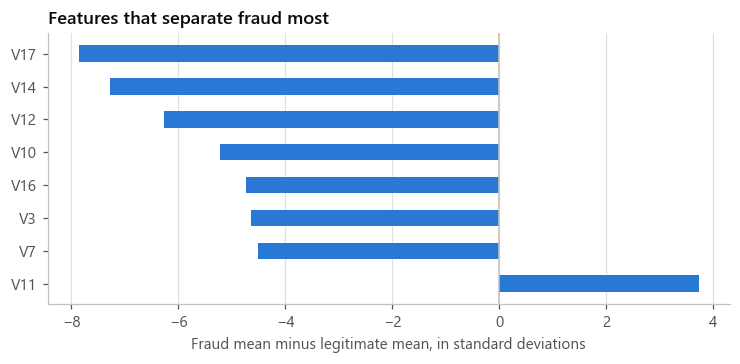

In [4]:
legit, fraud = df[df['Class'] == 0], df[df['Class'] == 1]
effect = ((fraud[V_COLUMNS].mean() - legit[V_COLUMNS].mean())
          / df[V_COLUMNS].std()).sort_values(key=abs, ascending=False)
top = effect.head(8)[::-1]

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.barh(top.index, top.values, height=0.5, color=BLUE)
ax.axvline(0, color='#c3c2b7', linewidth=1)
ax.grid(axis='x', color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
ax.set_xlabel('Fraud mean minus legitimate mean, in standard deviations')
ax.set_title('Features that separate fraud most', loc='left', color='#0b0b0b',
             fontweight='semibold')
plt.show()

In [5]:
beyond = (df[V_COLUMNS].abs() > 10).any(axis=1)
pd.DataFrame({
    'rows with any V feature beyond ±10': [beyond[df['Class'] == 0].mean(),
                                            beyond[df['Class'] == 1].mean()],
}, index=['Legitimate', 'Fraud']).style.format('{:.1%}')

,rows with any V feature beyond ±10
Legitimate,0.7%
Fraud,43.5%


## What this means for the benchmark

- **Metric and split.** 492 frauds among 284,807 rows means AUPRC, not accuracy, and stratified splits. The test split ends up with 98 frauds, so AUPRC gaps of a few hundredths between two single models are within noise.
- **Clipping bounds cost something before any noise is added.** Differential privacy needs fixed feature bounds (here ±10 on each V feature), and the extreme values those bounds cut off are mostly in fraud rows: 43.5% of frauds have at least one V feature beyond ±10, against 0.7% of legitimate transactions. Some of the private model's accuracy is lost here, not to noise.
- **Amount alone won't do it.** Frauds have a *lower* median amount (9.25 vs 22.00) but a heavier tail, so the model uses `log1p(Amount)` alongside the V features rather than any amount rule.
- **Time matters.** The fraud rate peaks at hours 2 and 4 of the 24-hour cycle (about 17 and 10 per 1,000) against roughly 1–2 per 1,000 for most of the day, which is why `hour` is a feature.
- **Synthetic data needs one generator per class.** A single generator trained on the whole table would see one fraud for every ~580 legitimate rows and barely learn what fraud looks like.